In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [4]:
df.shape

(22029, 16)

In [5]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [7]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


In [8]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


In [9]:
df['Campaign_ID'].nunique()

22029

In [10]:
df['Location'].unique()

array(['Houston', 'Washington, D.C.', 'Miami', 'Seattle', 'Chicago',
       'Los Angeles', 'Atlanta', 'Dallas', 'New York', 'San Francisco'],
      dtype=object)

In [11]:
df['Customer_Segment'].unique()

array(['Tech Enthusiasts', 'Foodies', 'Fashionistas',
       'Outdoor Adventurers', 'Health & Wellness'], dtype=object)

In [12]:
df['Campaign_Type'].value_counts()

,count
Campaign_Type,
Display,4450
Search,4441
Social Media,4412
Email,4388
Influencer,4338


In [13]:
df['Channel_Used'].value_counts()

,count
Channel_Used,
Facebook,3742
Google Ads,3694
Website,3688
Instagram,3649
YouTube,3632
Email,3624


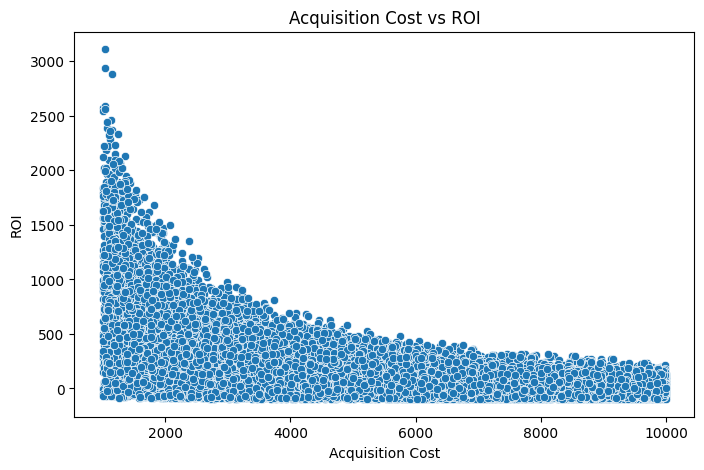

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Acquisition_Cost',
    y='ROI'
)

plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')

plt.show()

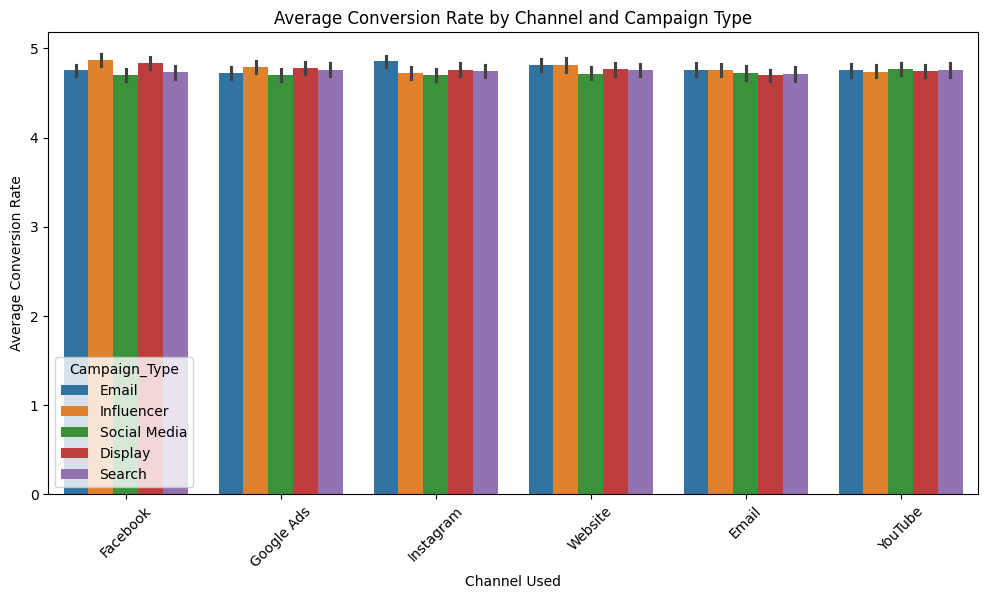

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Channel_Used',
    y='Conversion_Rate',
    hue='Campaign_Type'
)

plt.title('Average Conversion Rate by Channel and Campaign Type')
plt.xlabel('Channel Used')
plt.ylabel('Average Conversion Rate')

plt.xticks(rotation=45)

plt.show()

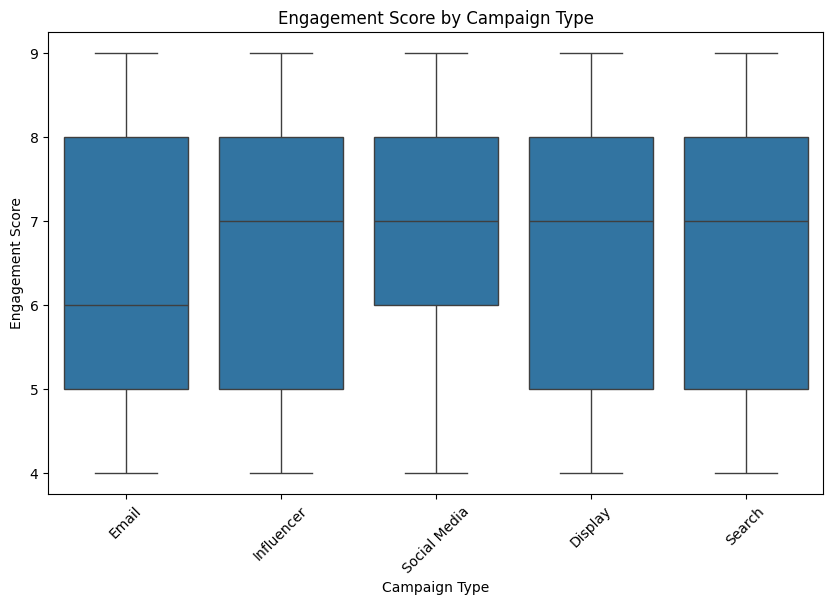

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Campaign_Type',
    y='Engagement_Score'
)

plt.title('Engagement Score by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Engagement Score')

plt.xticks(rotation=45)

plt.show()

In [17]:
company_roi = df.groupby('Company')['ROI'].mean().sort_values(ascending=False)

company_roi

,ROI
Company,
Alpha Innovations,187.802897
NexGen Systems,187.216772
Innovate Industries,181.513559
Data Tech Solutions,179.493878
TechCorp,178.355158


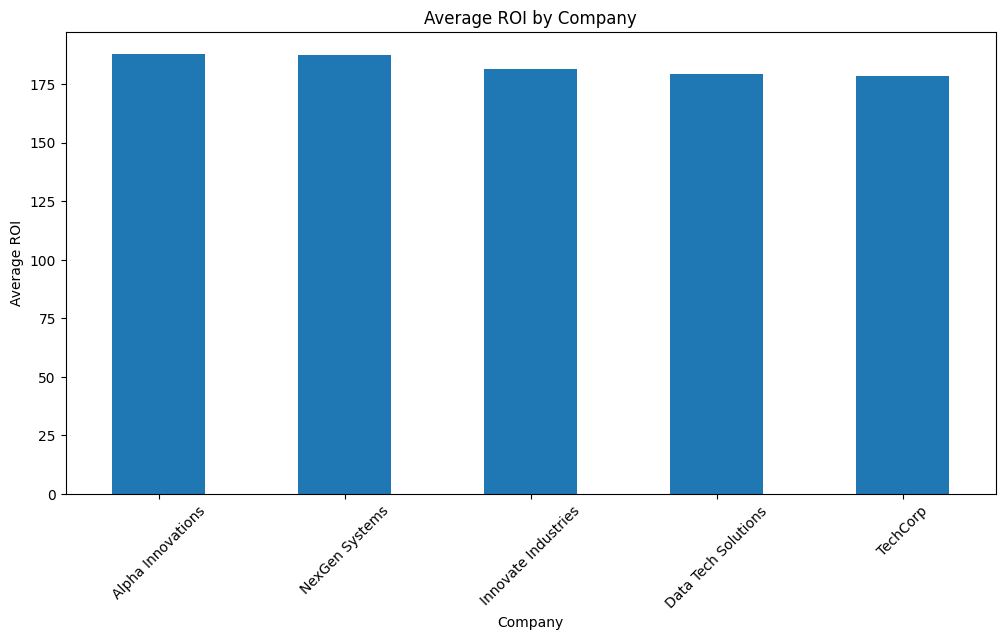

In [18]:
plt.figure(figsize=(12,6))

company_roi.plot(kind='bar')

plt.title('Average ROI by Company')
plt.xlabel('Company')
plt.ylabel('Average ROI')

plt.xticks(rotation=45)

plt.show()

In [19]:
corr = df[['Engagement_Score', 'Conversion_Rate']].corr()

corr

,Engagement_Score,Conversion_Rate
Engagement_Score,1.000000,0.010546
Conversion_Rate,0.010546,1.000000


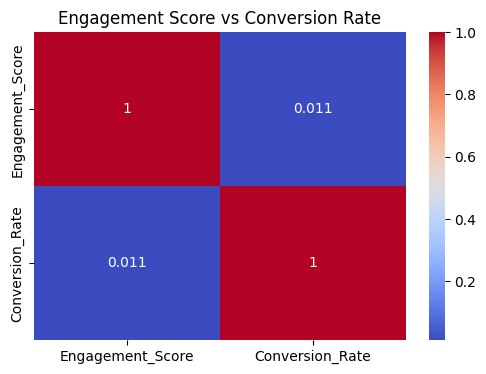

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Engagement Score vs Conversion Rate')

plt.show()

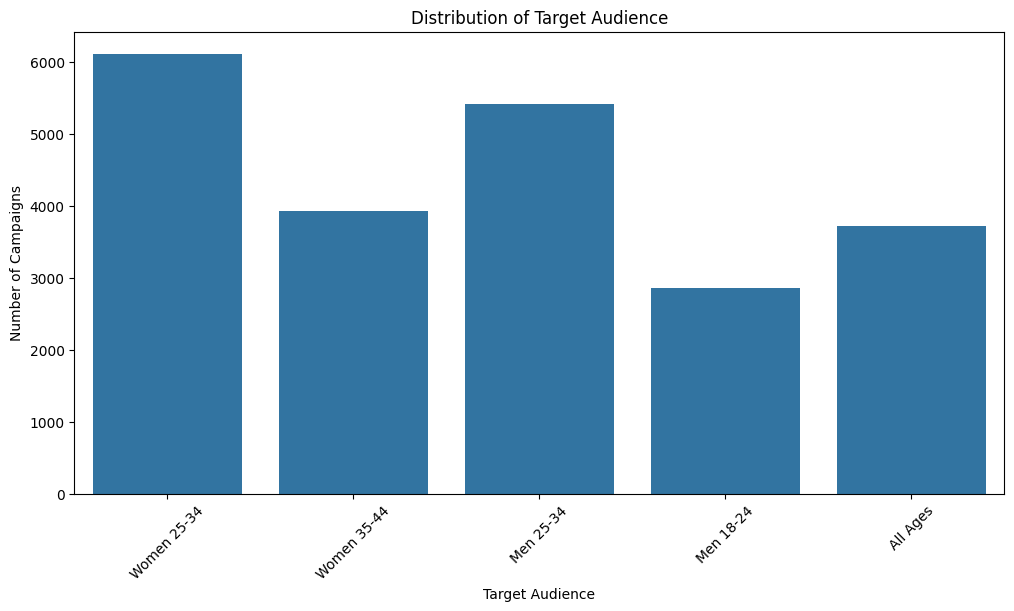

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Target_Audience'
)

plt.title('Distribution of Target Audience')
plt.xlabel('Target Audience')
plt.ylabel('Number of Campaigns')

plt.xticks(rotation=45)

plt.show()

In [3]:
segment_language = (
    df.groupby(['Language', 'Customer_Segment'])['Conversion_Rate']
    .mean()
    .reset_index()
)

In [4]:
highest_segment = (
    segment_language.loc[
        segment_language.groupby('Language')['Conversion_Rate'].idxmax()
    ]
    .reset_index(drop=True)
)

highest_segment

,Language,Customer_Segment,Conversion_Rate
0,English,Tech Enthusiasts,5.022731
1,French,Health & Wellness,4.689704
2,German,Foodies,4.705430
3,Mandarin,Health & Wellness,4.756125
4,Spanish,Foodies,4.663610
